# Autonomous Systems Portfolio 1  

|Name     |Studentnumber|Github    |
|---------|-------------|----------|
|Henry Lau|22122958     |HenryLau08|
|Michal|||
|Mohamed|||

Game: Connect 4

In [2]:
pip install pettingzoo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.5/852.5 kB 33.4 MB/s eta 0:00:00


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from pettingzoo.classic import connect_four_v3

# Initialize environment
env = connect_four_v3.env(render_mode="rgb_array")
env.reset(seed=42)

# Convert Observation
def convert_observation(obs):
    """
    Convert PettingZoo Connect Four observation (6x7x2)
    to a 2D board (6x7) with:
        0 = empty
        1 = player 1
        2 = player 2
    """
    board = np.zeros((6, 7), dtype=int)

    for i in range(6):
        for j in range(7):
            if obs[i, j, 0] == 1:
                board[i, j] = 1
            elif obs[i, j, 1] == 1:
                board[i, j] = 2

    return board

# Print Board
def print_board(board, mask):
    print("\nCurrent board:")

    visual = []
    for i in range(6):
        row = []
        for j in range(7):
            if board[i, j] == 1:
                row.append("X")
            elif board[i, j] == 2:
                row.append("O")
            else:
                row.append("·")
        visual.append(row)

    for row in visual:
        print(" ".join(row))

    print("\nColumns:", end=" ")
    for i in range(7):
        if mask[i]:
            print(i, end=" ")
        else:
            print("x", end=" ")
    print("\n")

# Human Action
def get_human_action(observation):
    mask = observation["action_mask"]
    board = observation["board"]

    print_board(board, mask)

    while True:
        try:
            move = int(input("Choose a column (0-6): "))
            if 0 <= move < 7 and mask[move]:
                return move
            else:
                print("Invalid move. Choose an available column.")
        except ValueError:
            print("Enter a valid number.")

# Strategy Placeholder
def strategy_player_2(observation, agent):
    """
    Fill in your strategy here.

    observation: dict with:
        - "board": 6x7 numpy array
        - "action_mask": valid moves

    agent: "player_0" or "player_1"
    """
    mask = observation["action_mask"]

    # TODO: Replace with your own strategies
    return np.random.choice(np.where(mask)[0])

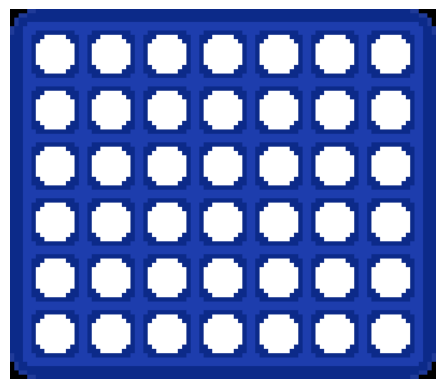


Current board:
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·

Columns: 0 1 2 3 4 5 6 

Choose a column (0-6): 4


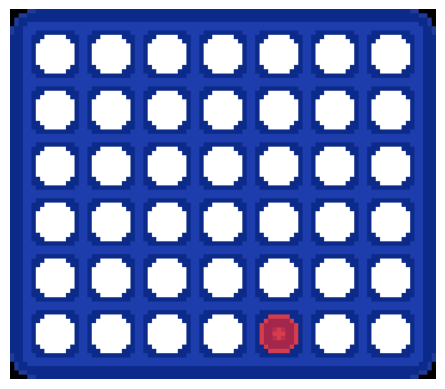

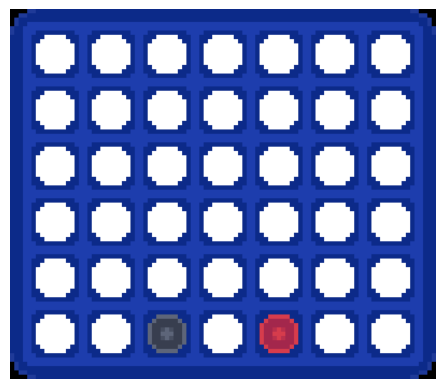


Current board:
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · O · X · ·

Columns: 0 1 2 3 4 5 6 

Choose a column (0-6): 4


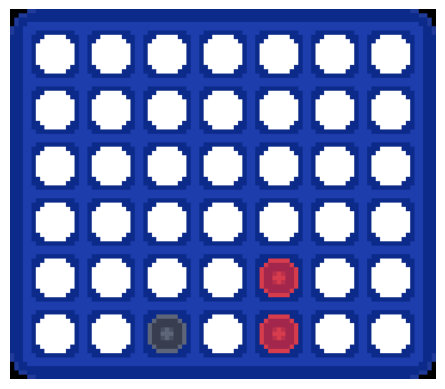

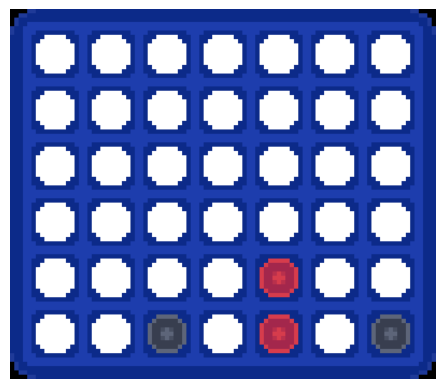


Current board:
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · X · ·
· · O · X · O

Columns: 0 1 2 3 4 5 6 

Choose a column (0-6): 4


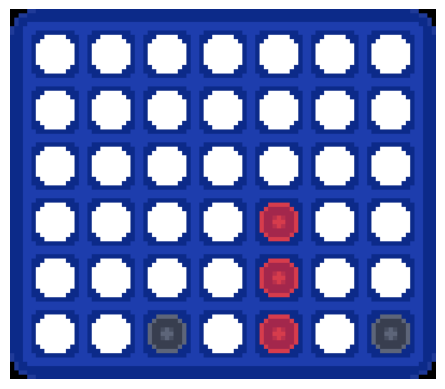

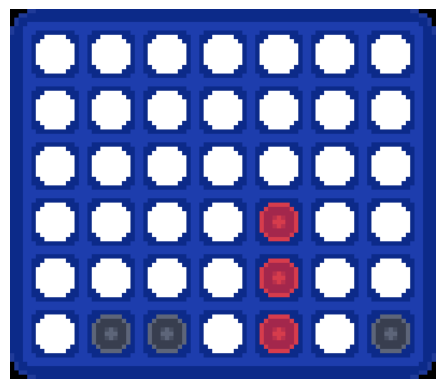


Current board:
· · · · · · ·
· · · · · · ·
· · · · · · ·
· · · · X · ·
· · · · X · ·
· O O · X · O

Columns: 0 1 2 3 4 5 6 

Choose a column (0-6): 4


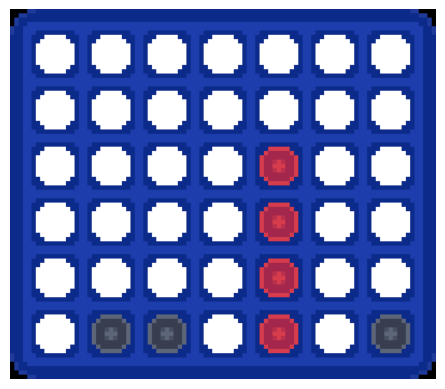

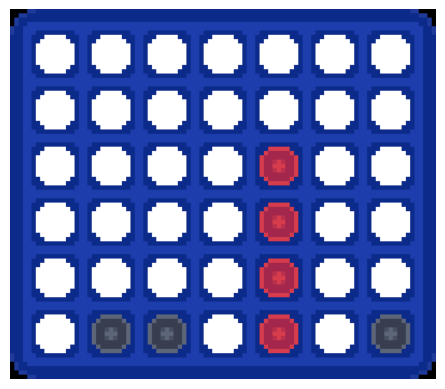


You win!


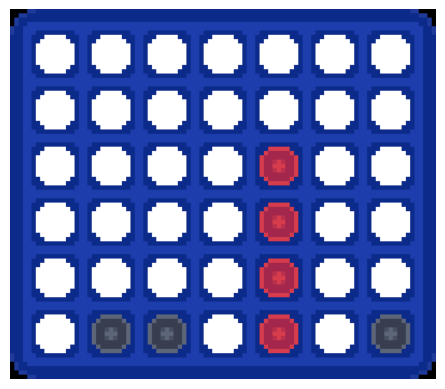

In [7]:
# Render initial state
rgb_image = env.render()
plt.imshow(rgb_image)
plt.axis('off')
plt.show()

# Game Loop
for agent in env.agent_iter():
    raw_observation, reward, termination, truncation, info = env.last()

    if termination or truncation:
        if reward == 1:
            print("\nYou win!" if agent == "player_0" else "\nComputer wins!")
        elif reward == 0:
            print("\nDraw!")
        action = None

    else:
        board = convert_observation(raw_observation["observation"])
        observation = {
            "board": board,
            "action_mask": raw_observation["action_mask"]
        }

        # Player 0 = Human, Player 1 = AI
        if agent == "player_0":
            action = get_human_action(observation)
        else:
            action = strategy_player_2(observation, agent)

    env.step(action)

    rgb_image = env.render()
    plt.imshow(rgb_image)
    plt.axis('off')
    plt.show()


env.close()